In [27]:
#Building linear Regression for multiple features 

In [22]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [33]:
#Loading the dataset from the course i did at coursera(IBM)
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)
df.sample(20)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
631,2014,KIA,SPORTAGE AWD,SUV - SMALL,2.0,4,A6,X,12.7,9.7,11.4,25,262
84,2014,BMW,328i xDRIVE GRAN TURISMO,FULL-SIZE,2.0,4,A8,Z,10.6,7.2,9.1,31,209
895,2014,PORSCHE,CAYENNE S HYBRID,SUV - STANDARD,3.0,6,A8,Z,11.8,9.9,10.9,26,251
40,2014,AUDI,Q5 HYBRID,SUV - SMALL,2.0,4,AS8,Z,9.9,8.3,9.2,31,212
849,2014,NISSAN,MURANO AWD,SUV - SMALL,3.5,6,AV,X,13.2,10.1,11.8,24,271
555,2014,JAGUAR,XJ AWD,FULL-SIZE,3.0,6,AS8,Z,14.6,9.6,12.4,23,285
564,2014,JAGUAR,XK COUPE,MINICOMPACT,5.0,8,AS6,Z,14.8,9.9,12.6,22,290
725,2014,MERCEDES-BENZ,C 300 4MATIC FFV,COMPACT,3.5,6,AS7,E,16.4,11.1,14.0,20,224
263,2014,CHEVROLET,SUBURBAN 4WD,SUV - STANDARD,5.3,8,A6,X,16.0,11.1,13.8,20,317
981,2014,TOYOTA,FJ CRUISER 4WD,SUV - SMALL,4.0,6,M6,X,15.4,12.1,13.9,20,320


In [24]:
#Since most of the features will not be important to the model they nee d to be drop
df = df.drop(["MODELYEAR","MAKE","MODEL","VEHICLECLASS","TRANSMISSION","FUELTYPE"], axis = 1)
df.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
1015,1.8,4,9.9,7.2,8.7,32,200
288,3.6,6,12.4,7.7,10.3,27,237
952,2.0,4,9.6,7.1,8.5,33,196
325,3.6,6,17.7,13.0,15.6,18,250
593,2.4,4,11.4,8.7,10.2,28,235


In [25]:
#Now i have to use the describe function to see the statistical relationship between the features 
df.describe()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [26]:
#let now look at the correlation relationship between the features 
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [27]:
#The correlation function help you to know how each feature relate to each other in other words it help you to select the best features for the model by knowing how each feature correlate to the target 

In [28]:
df = df.drop(["CYLINDERS","FUELCONSUMPTION_CITY","FUELCONSUMPTION_HWY","FUELCONSUMPTION_COMB"], axis = 1)
df.sample(5)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
439,5.3,17,380
984,3.5,25,264
232,2.4,32,200
235,2.4,27,244
320,2.4,32,202


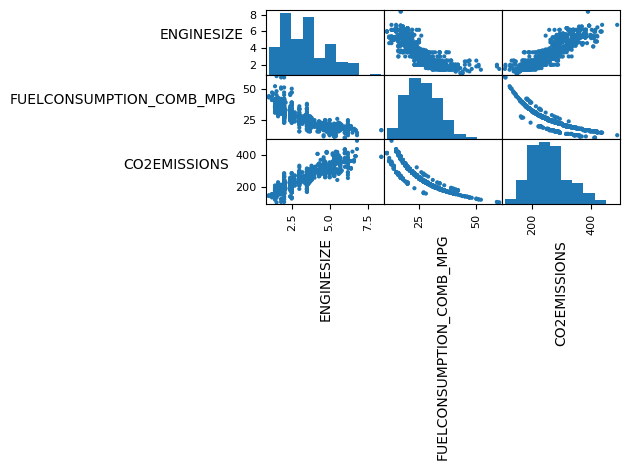

In [29]:
axes = pd.plotting.scatter_matrix(df, alpha = 1)
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha("right")
plt.tight_layout()
plt.gcf().subplots_adjust(wspace = 0, hspace = 0)
plt.show()

In [30]:
#The visualization helps in selecting relevant features before training the machine learning model.
#Etracting the features and the labels from the dataset
#And convert them into numpy as well

In [31]:
X = df.iloc[:,[0,1]].to_numpy()
y = df.iloc[:,[2]].to_numpy()

In [32]:
scaler = StandardScaler()
x_std = scaler.fit_transform(X)

In [21]:
print(x_std)

[[-0.9512918   0.87855306]
 [-0.66865251  0.34273362]
 [-1.30459092  2.88787597]
 ...
 [-0.24469358 -0.32704069]
 [-0.10337393 -0.19308583]
 [-0.10337393 -0.59495041]]


In [79]:
pd.DataFrame(x_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [80]:
#Splitting the dataset into train and test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)

In [81]:
print(X_train)

[[ 2.  23. ]
 [ 3.6 25. ]
 [ 5.4 15. ]
 ...
 [ 4.4 20. ]
 [ 1.8 33. ]
 [ 5.6 16. ]]


In [82]:
#Building the model
regressor = LinearRegression()
regressor.fit(X_train,y_train)
coef = regressor.coef_
intercept = regressor.intercept_

In [83]:
print(f"The coefficient is {coef}")

The coefficient is [[17.77358881 -5.01779141]]


In [84]:
print(f"This is the intercep {intercept}")

This is the intercep [329.55860182]


In [85]:
#Ensuring X1,X2 and y_test have compatible shape of 3D plotting 

In [86]:
X1 = X_test[:,0] if X_test.ndim > 1 else X_test
X2 = X_test[:,0] if X_test.ndim > 1 else np.zeros.like(X1)
#Create a maeshgrid for plotting the regression plane
X1_surf, X2_surf = np.meshgrid(np.linspace(X1.min(),X1.max(),100),
                               np.linspace(X2.min(), X2.max(),100))
y_surf = intercept + coef[0,0] * X1_surf + coef[0,1] * X2_surf

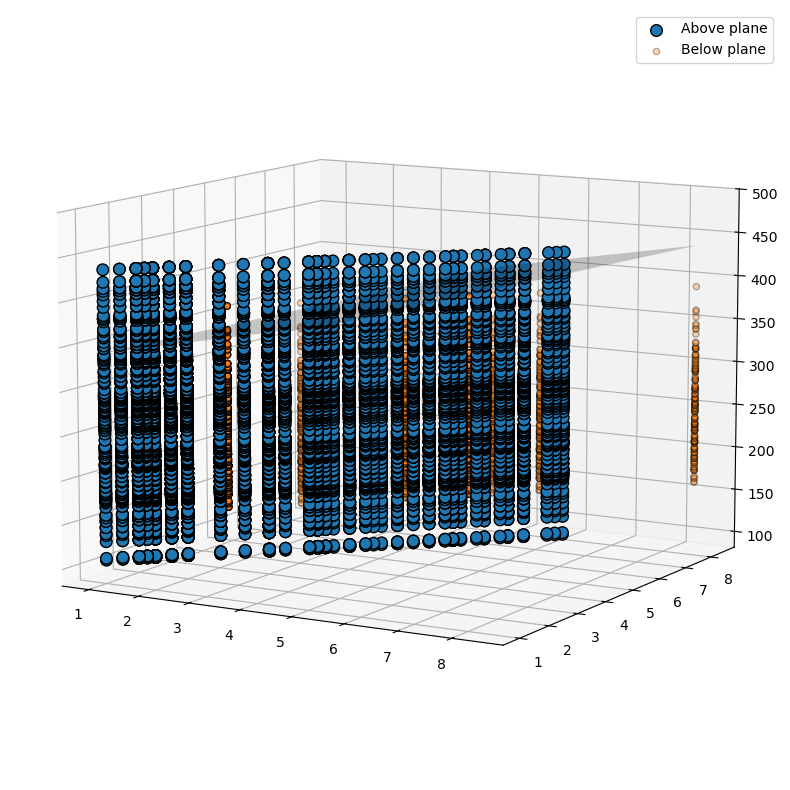

In [87]:
# Predict y values
y_pred = regressor.predict(X_train.reshape(-1,1)) if X_train.ndim == 1 else regressor.predict(X_test)

# Create masks
above_plane = y_test >= y_pred
below_plane = y_test < y_pred

# Convert to 1D arrays if needed
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20,8))

ax = fig.add_subplot(111, projection='3d')

# Plot points above the plane
ax.scatter(
    X1[above_plane],
    X2[above_plane],
    y_test[above_plane],
    label="Above plane",
    s=70,
    alpha=1,
    edgecolor="k"
)

# Plot points below the plane
ax.scatter(
    X1[below_plane],
    X2[below_plane],
    y_test[below_plane],
    label="Below plane",
    alpha=0.3,
    edgecolor="k"
)

# Plot regression plane
ax.plot_surface(
    X1_surf,
    X2_surf,
    y_surf,
    color="k",
    alpha=0.21
)

# Set viewing angle
ax.view_init(elev=10)

ax.legend()

plt.tight_layout()
plt.show()

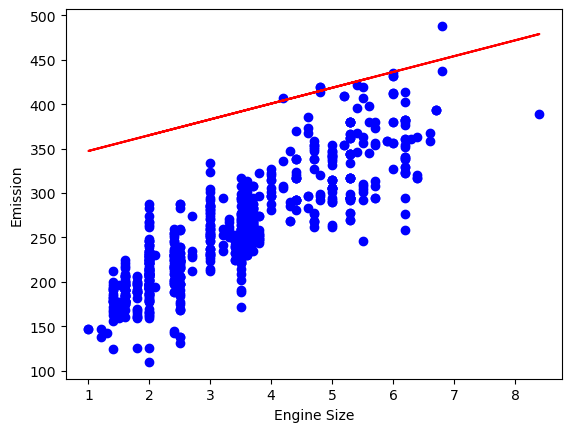

In [88]:
plt.scatter(X_train[:,0], y_train[:,0], color="blue")

plt.plot(X_train[:,0],coef[0,0] * X_train[:,0] + intercept[0],color='red')

plt.xlabel("Engine Size")
plt.ylabel("Emission")

plt.show()

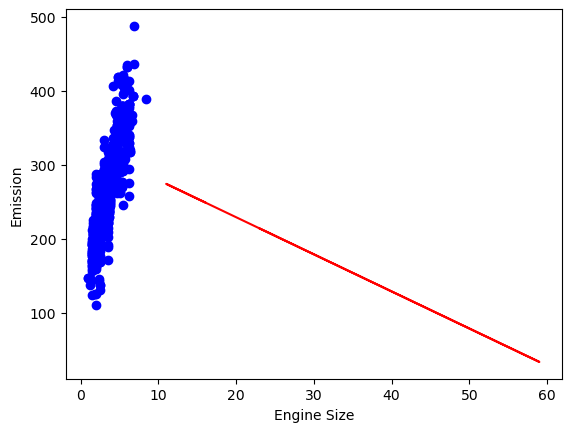

In [89]:
plt.scatter(X_train[:,0], y_train[:,0], color="blue")

plt.plot(X_train[:,1],coef[0,1] * X_train[:,1] + intercept[0],color='red')

plt.xlabel("Engine Size")
plt.ylabel("Emission")

plt.show()

In [90]:
y_pred = regressor.predict(X_test)

In [91]:
pd.DataFrame(y_pred)

,0
0,307.720850
1,246.250212
2,283.152111
3,237.363418
4,209.554246
...,...
316,204.536454
317,353.509543
318,339.399024
319,170.560703


In [97]:
from sklearn.metrics import r2_score, mean_squared_error

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.8896011769542103
Mean Squared Error: 445.2933232976172
